In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

In [2]:
GREEN = "darkgreen"
BLUE = "steelblue"

## 1. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a simple, instance-based learning algorithm used for classification and regression. In both cases, the input consists of the k closest training examples in the feature space. The output depends on whether KNN is used for classification or regression:

- **In KNN classification**, the output is a class membership. An object is classified by a majority vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors (k is a positive integer, typically small). If k=1, then the object is simply assigned to the class of its nearest neighbor.
  
- **In KNN regression**, the output is the property value for the object. This value is the average of the values of its k nearest neighbors.

KNN is a type of lazy learning, where the function is only approximated locally and all computation is deferred until classification. The two most import things to remember about nearest neighbors are:

 - **Pre-Processing**: Normalize or standardize your data beforehand. This ensures that all features contribute equally to the distance calculations and can sometimes speed up distance computations.
 - **Feature relevance**: Nearest neibours does not look at the targets to select neighbours! So features themselves should be representetive for predicting the target! Having garbage features destroys k-NN.

#### Tips and Tricks for Choosing a Good Value of k 

1. **Avoid Small k Values**: A very small value of k (like $k=1$ or $k=2$) can be noisy and will have a high influence from the noise in the dataset. It can lead to overfitting, where the classifier adheres too closely to the training data.
   
2. **Avoid Large k Values**: A very large value of k can smooth out the prediction too much and lead to underfitting, losing the ability to capture the nuances in the data.
   
3. **Use Cross-Validation**: A good practice is to use cross-validation to find the optimal $k$. This involves dividing your dataset into a training set and a validation set, then trying out several values of $k$ and choosing the one that performs best on the validation set.
   
4. **Consider the Square Root Rule**: A commonly used rule of thumb is to choose $k$ as the square root of the number of data points in the training set.
   
5. **Weighted KNN**: Instead of giving equal weight to all $k$ neighbors, you can weight the neighbors by the inverse of their distance to the point being classified. This gives greater influence to closer neighbors.
   
6. **Domain Knowledge**: Sometimes the choice of $k$ can be informed by domain knowledge or the context of the problem.

Text(0, 0.5, 'sepal width (cm)')

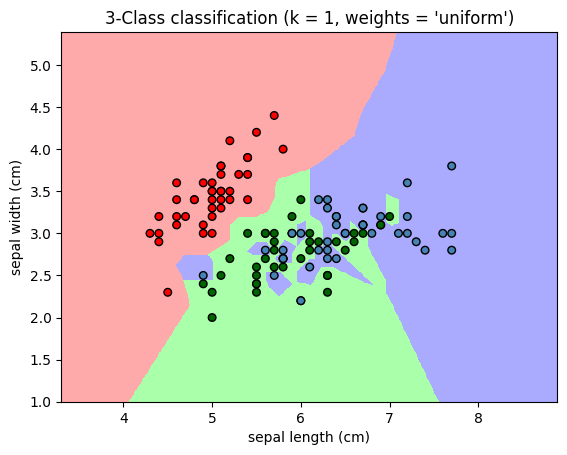

In [3]:
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features for simplicity
y = iris.target

# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the model
k = 1  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Create color maps for visualization
colors = ['#FF0000', GREEN, BLUE]
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(colors)

# Plot the decision boundary by assigning a color in the color map to each mesh point.
mesh_step_size = .01  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step_size),
                     np.arange(y_min, y_max, mesh_step_size))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=30)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f"3-Class classification (k = {k}, weights = 'uniform')")

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

### Nieuwe punten classificeren

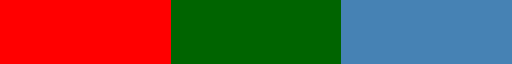

In [4]:
# take a look at the colors
cmap_bold

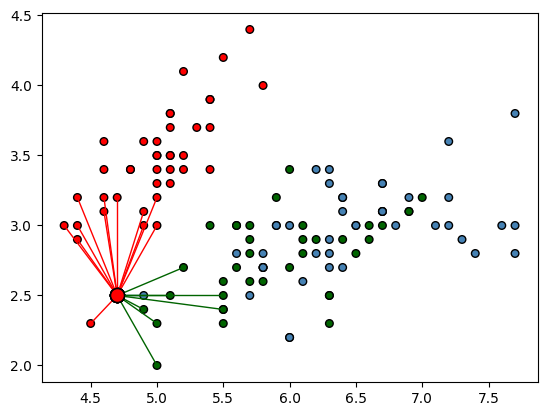

In [5]:
point = np.array([4.7, 2.5]).reshape(1, -1)
num_neighbours = 20 # len(X_train)
show_classification = True

knn = KNeighborsClassifier(n_neighbors=num_neighbours)
knn.fit(X_train, y_train)
predicted_class  = knn.predict(point)[0]
distances, indices = knn.kneighbors(point)

fig, ax = plt.subplots()
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=30)
if show_classification:
    lw = max(1, 8 / (num_neighbours+1))
    for index in indices[0]:
        ax.plot([point[0][0], X_train[index][0]], [point[0][1], X_train[index][1]], color = colors[y_train[index]], lw = lw)
        ax.plot(point[0][0], point[0][1], marker = 'o', color = colors[predicted_class], markersize = 10, markeredgecolor = 'k')
else:
    ax.plot(point[0][0], point[0][1], marker = 'o', color = 'gray', markersize = 10, markeredgecolor = 'k')

## Tips for Large Datasets to Avoid Long Computation Time

1. **Dimensionality Reduction**: Reducing the number of features in the dataset through methods like PCA (Principal Component Analysis) can decrease the distance calculation time.

2. **Approximate Nearest Neighbor Algorithms**: Instead of calculating exact distances to all points, use approximate methods like k-d trees, ball trees, or locality-sensitive hashing. These methods can significantly reduce computation time by avoiding exhaustive search. These different algorithms can be selected in the `algorithm` parameter of the `KNeighborsClassifier`.

3. **Parallel Processing**: Utilize parallel processing to distribute the computation of distances across multiple CPU cores or machines if your environment supports it.

4. **Sampling**: If the dataset is extremely large, consider working with a representative sample rather than the full dataset. However, be cautious as this may introduce sampling bias.

5. **Caching**: Store the distances between points if you expect to query the same points multiple times. This avoids redundant calculations.

6. **Use a Faster Distance Metric**: The choice of distance metric can affect computation time. For example, the Manhattan distance (L1) can be computed faster than the Euclidean distance (L2) in many cases.

### The Curse of Dimensionality and Feature Relevance in K-Nearest Neighbors

#### The Curse of Dimensionality

K-Nearest Neighbors (KNN) can suffer significantly from the curse of dimensionality, a phenomenon that occurs when the feature space becomes too high-dimensional. Here's how this issue affects KNN:

1. **Distance Metric Becomes Less Informative**: As the number of features grows, the distance between data points becomes less meaningful. In high-dimensional spaces, all points tend to be far away from each other, making it difficult to determine which are the closest neighbors.

2. **Sparsity of Data**: With more dimensions, the volume of the space increases exponentially, and the available data becomes sparse. This sparsity requires exponentially more data to maintain the same level of model performance.

3. **Increased Computational Complexity**: More features mean more calculations to determine the nearest neighbors. This can lead to a significant increase in computation time, especially since KNN requires distance calculations for each query instance.

4. **Overfitting Risk**: KNN can overfit in high-dimensional spaces if many features are irrelevant or redundant, as noise in the data can be interpreted as meaningful variance.

#### Feature Relevance

KNN assumes that all features are equally important in determining the similarity between instances. However, this is not always the case, and some features may be irrelevant or less important for predicting the target value:

1. **Irrelevant Features**: Features that do not contribute to the predictive power of the model can introduce noise into the distance calculations, leading to poor performance.

2. **Redundant Features**: Features that are highly correlated with each other can distort the distance metric, giving undue weight to certain dimensions.

3. **Scale of Features**: Features on larger scales can dominate the distance calculations, even if they are not the most informative.